## Keras-CNN-CIFAR-10 
## CIFAR-10 | CNN | CLASSIFIER | TENSORFLOW | KERAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import datasets cifar 10
from tensorflow.keras.datasets import cifar10

In [3]:
(x_train, y_train),(x_test, y_test) = cifar10.load_data()

## Visual images

In [4]:
x_train.shape

(50000, 32, 32, 3)

In [5]:
x_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

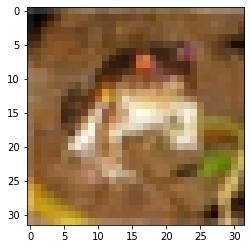

In [6]:
plt.imshow(x_train[0]);

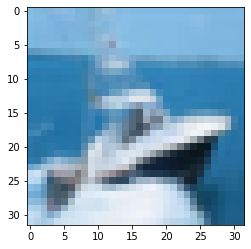

In [7]:
plt.imshow(x_train[8]);

## Preprocessing data y | label | hot end coding

In [8]:
y_train.shape

(50000, 1)

In [9]:
y_test.shape

(10000, 1)

In [10]:
from tensorflow.keras.utils import to_categorical

In [11]:
# mencari nilai classes
y_classes = to_categorical(y_train)

In [12]:
y_classes.shape

(50000, 10)

In [13]:
y_classes.shape[1]

10

In [14]:
y_cat_train = to_categorical(y_train, num_classes=10)

In [15]:
y_cat_test = to_categorical(y_test, num_classes=10 )

----
## Normalization data x

In [16]:
x_train.shape

(50000, 32, 32, 3)

In [17]:
x_test.shape

(10000, 32, 32, 3)

In [18]:
x_train[0].max()

255

In [19]:
x_train[0].min()

0

In [20]:
x_train = x_train/255

In [21]:
x_test = x_test/255

Tidak membutuhkan langkah reshape karena datanya sudah 3 dimensi

-----
## Create Model

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten

In [23]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size=(3,3), input_shape=(32, 32, 3), activation='relu'))
model.add(MaxPool2D(pool_size = (2,2)))

model.add(Conv2D(filters = 32, kernel_size=(3,3), input_shape=(32, 32, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(256, activation ='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation ='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics =['accuracy'])

In [24]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 15, 15, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 6, 6, 32)         0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 1152)              0         
                                                                 
 dense (Dense)               (None, 256)               2

## Add EarlyStopping

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

----
## Fitting Model

In [27]:
model.fit(x_train, y_cat_train, 
          epochs = 20, 
          validation_data= (x_test, y_cat_test), 
          callbacks =[early_stop])

Epoch 1/20
1563/1563 [==============================] - 176s 110ms/step - loss: 1.4801 - accuracy: 0.4632 - val_loss: 1.2098 - val_accuracy: 0.5642
Epoch 2/20
1563/1563 [==============================] - 169s 108ms/step - loss: 1.1268 - accuracy: 0.6044 - val_loss: 1.0426 - val_accuracy: 0.6328
Epoch 3/20
1563/1563 [==============================] - 172s 110ms/step - loss: 0.9826 - accuracy: 0.6563 - val_loss: 0.9653 - val_accuracy: 0.6615
Epoch 4/20
1563/1563 [==============================] - 171s 109ms/step - loss: 0.8899 - accuracy: 0.6888 - val_loss: 0.9681 - val_accuracy: 0.6648
Epoch 5/20
1563/1563 [==============================] - 155s 99ms/step - loss: 0.8144 - accuracy: 0.7162 - val_loss: 0.8812 - val_accuracy: 0.6975
Epoch 6/20
1563/1563 [==============================] - 152s 97ms/step - loss: 0.7494 - accuracy: 0.7373 - val_loss: 0.9137 - val_accuracy: 0.6905
Epoch 7/20
1563/1563 [==============================] - 152s 97ms/step - loss: 0.6880 - accuracy: 0.7582 - val_los

## Evaluation

In [28]:
losses = pd.DataFrame(model.history.history)

In [29]:
losses

,loss,accuracy,val_loss,val_accuracy
0,1.480130,0.46316,1.209810,0.5642
1,1.126768,0.60436,1.042569,0.6328
2,0.982619,0.65634,0.965304,0.6615
3,0.889909,0.68882,0.968064,0.6648
4,0.814445,0.71616,0.881242,0.6975
5,0.749446,0.73730,0.913697,0.6905
6,0.688026,0.75820,0.899213,0.6991


In [30]:
plt.style.use(['science','notebook','grid'])

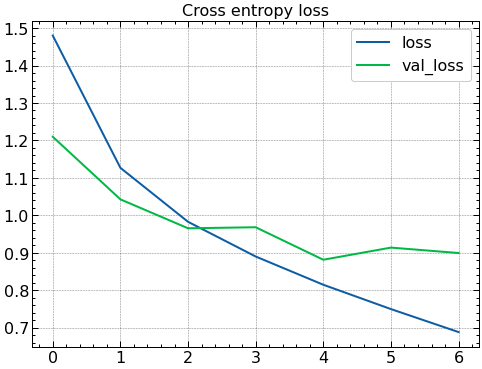

In [31]:
losses[['loss','val_loss']].plot()
plt.title('Cross entropy loss');

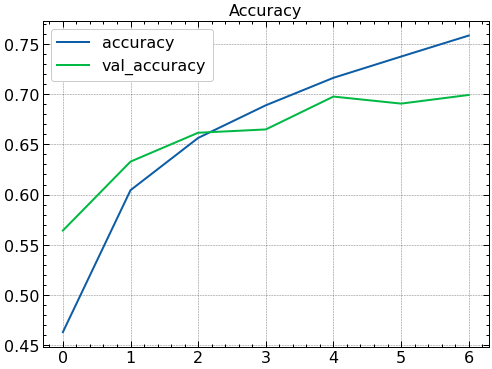

In [32]:
losses[['accuracy','val_accuracy']].plot()
plt.title('Accuracy');

In [33]:
model.metrics_names

['loss', 'accuracy']

In [34]:
model.evaluate(x_test, y_cat_test)

313/313 [==============================] - 10s 30ms/step - loss: 0.8992 - accuracy: 0.6991


[0.8992125988006592, 0.6991000175476074]

----------
## Prediction

In [35]:
prediction = np.argmax(model.predict(x_test), axis =-1)

313/313 [==============================] - 10s 29ms/step


In [36]:
y_cat_test.shape

(10000, 10)

In [37]:
y_cat_test[0]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [38]:
prediction 

array([3, 8, 8, ..., 5, 1, 7], dtype=int64)

## Evaluation metrics

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

In [40]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.68      0.80      0.74      1000
           1       0.81      0.82      0.82      1000
           2       0.58      0.63      0.60      1000
           3       0.51      0.49      0.50      1000
           4       0.61      0.69      0.65      1000
           5       0.67      0.53      0.59      1000
           6       0.86      0.69      0.77      1000
           7       0.70      0.76      0.73      1000
           8       0.82      0.79      0.81      1000
           9       0.79      0.77      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



In [41]:
confusion_matrix(y_test, prediction)

array([[803,  17,  44,  10,  24,   2,   5,  14,  54,  27],
       [ 27, 821,   9,   9,   8,   6,   6,   7,  30,  77],
       [ 81,  10, 632,  58,  89,  35,  35,  43,   9,   8],
       [ 37,  11,  90, 495, 101, 126,  32,  63,  23,  22],
       [ 33,   3,  89,  54, 694,  17,  17,  79,  10,   4],
       [ 26,   3,  76, 200,  56, 530,   7,  81,  10,  11],
       [ 11,  11,  84,  77,  61,  29, 694,  14,   9,  10],
       [ 24,   2,  38,  41,  81,  30,   2, 757,   3,  22],
       [101,  32,  17,  10,  10,   5,   2,   9, 791,  23],
       [ 38, 101,  17,  12,   7,   8,   4,  15,  24, 774]], dtype=int64)

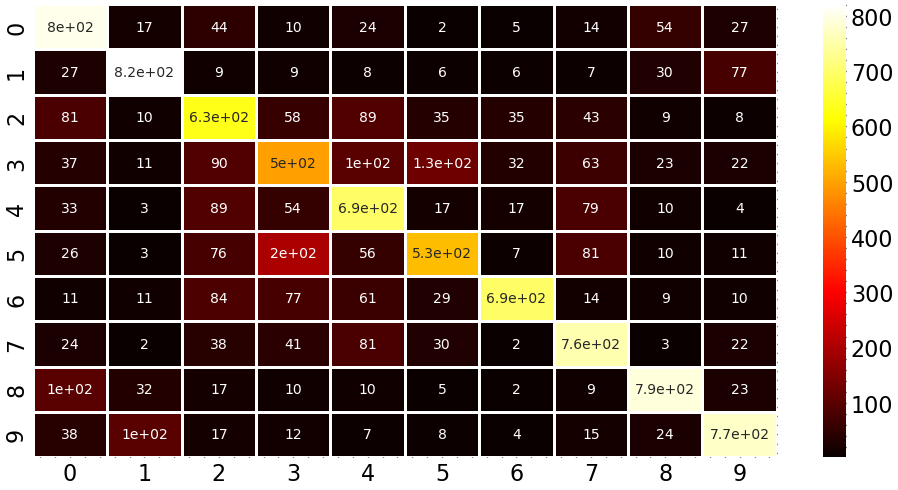

In [42]:
plt.figure(figsize=(12, 6), dpi=100)
sns.heatmap(confusion_matrix(y_test, prediction), annot=True, lw=2, cmap='hot');

## Prediction image

In [43]:
test_image = x_train[9]

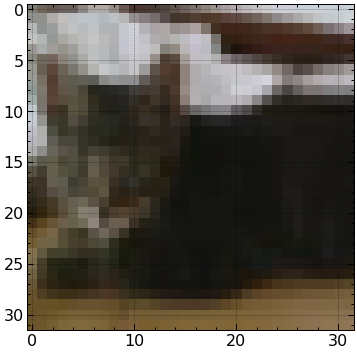

In [44]:
plt.imshow(test_image);

In [45]:
predict = np.argmax(model.predict(test_image.reshape(1,32, 32, 3)), axis=-1)

1/1 [==============================] - 0s 144ms/step


In [46]:
predict

array([3], dtype=int64)

https://www.cs.toronto.edu/~kriz/cifar.html